Датасет `wine.csv` містить дані якість вина. Цільовою змінною є `quality`. 


Датасет `wine_predict.csv` не містить значень цільової змінної і призначений для зовнішнього оцінювання.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Налаштування стилю для графіків
sns.set_style("whitegrid")

## Завдання 1

[2 бали] 

Імпортувати датасет `wine.csv` у об'єкт DataFrame і провести попередній аналіз даних засобами pandas, matplotlib, seaborn.   

In [3]:
sns.set_style("whitegrid")

# Завантаження датасету
try:
    df = pd.read_csv('wine.csv', sep=',')
    print("✅ Датасет 'wine.csv' успішно завантажено.")
except FileNotFoundError:
    print("❌ Помилка: Файл 'wine.csv' не знайдено. Переконайтеся, що файл знаходиться у коректній директорії.")
    df = None

✅ Датасет 'wine.csv' успішно завантажено.


In [4]:
if df is not None:
    print("## 📊 Перші 5 рядків датасету")
    print(df.head())

    print("\n## 📋 Загальна інформація про датасет")
    df.info()

    print("\n## 🔍 Перевірка на пропущені значення")
    print(df.isnull().sum())

    print("\n## 🔢 Описова статистика")
    print(df.describe().T)

## 📊 Перші 5 рядків датасету
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.8              0.18         0.31            12.2      0.053   
1            7.3              0.51         0.26             3.3      0.090   
2            6.0              0.24         0.27             1.9      0.048   
3            5.9              0.62         0.28             3.5      0.039   
4            6.7              0.27         0.12             1.3      0.041   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 46.0                 140.0   0.9980  3.06       0.53   
1                  7.0                 135.0   0.9944  3.01       0.52   
2                 40.0                 170.0   0.9938  3.64       0.54   
3                 55.0                 152.0   0.9907  3.44       0.44   
4                 62.0                 138.0   0.9921  3.21       0.42   

   alcohol  quality  
0      8.9        3  
1      8.8   

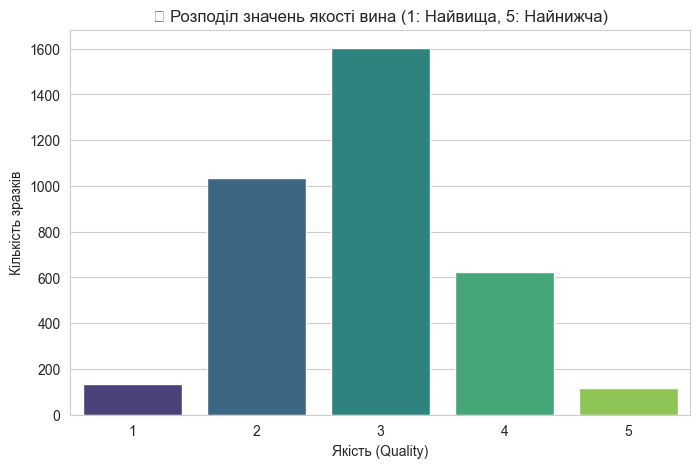


## 📊 Розподіл класів якості
quality
1     3.865833
2    29.448550
3    45.565662
4    17.765776
5     3.354179
Name: proportion, dtype: float64


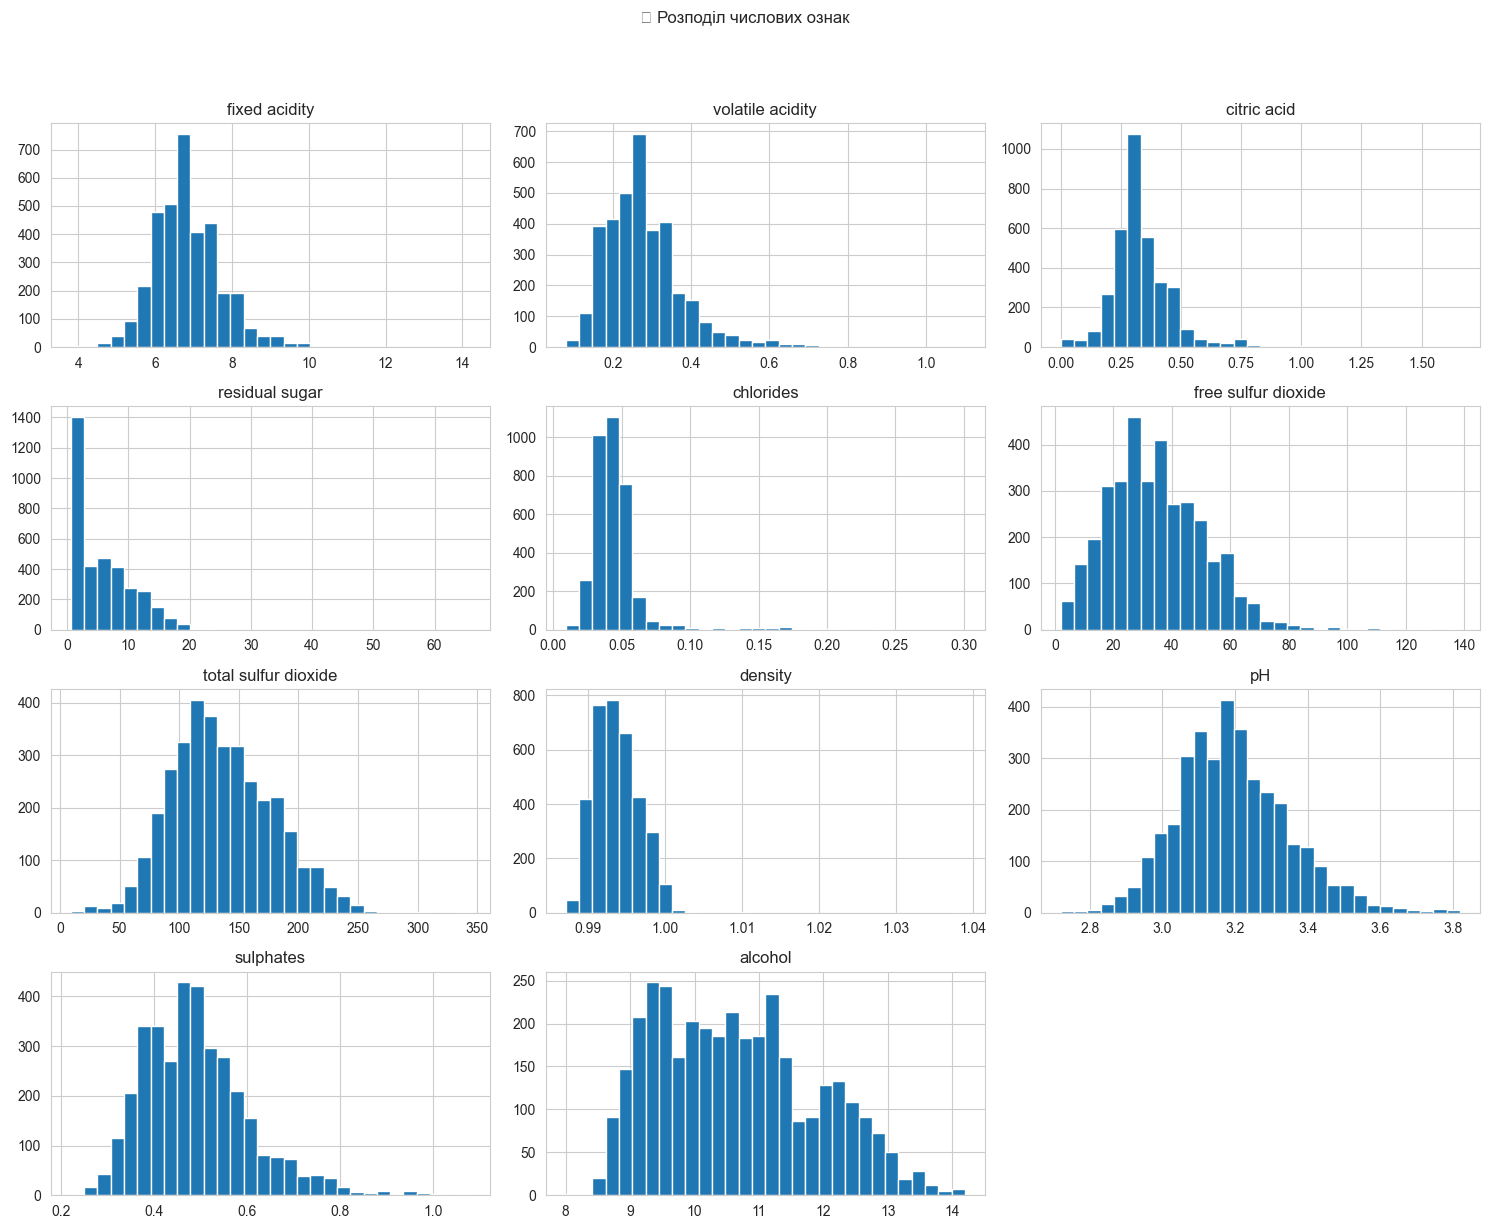

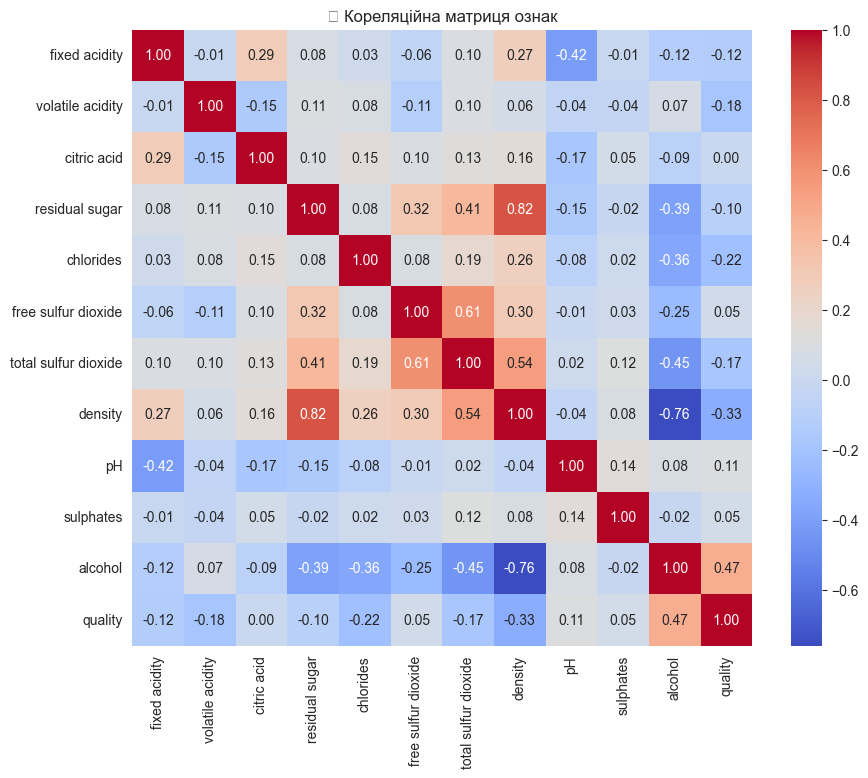


## 🎯 Кореляція з цільовою змінною 'quality' (1: Найвища Якість)
density                -0.331493
chlorides              -0.220588
volatile acidity       -0.182719
total sulfur dioxide   -0.173203
fixed acidity          -0.120328
residual sugar         -0.097768
citric acid             0.000382
free sulfur dioxide     0.045015
sulphates               0.050210
pH                      0.108356
alcohol                 0.469393
quality                 1.000000
Name: quality, dtype: float64


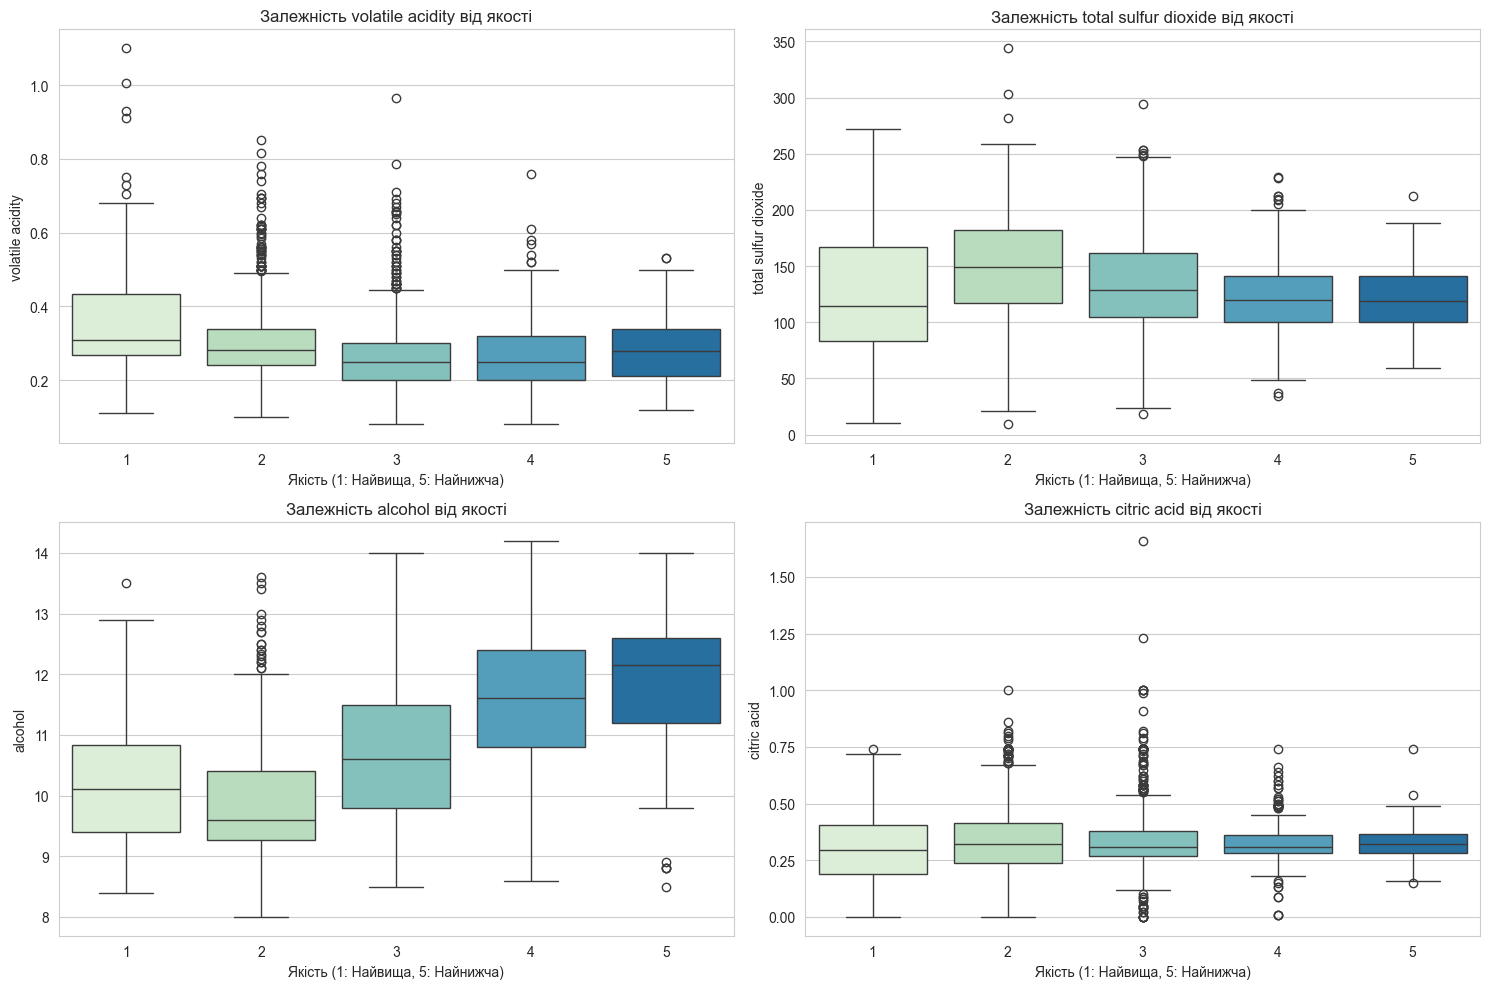

In [27]:
if df is not None:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='quality', data=df, palette='viridis')
    plt.title('🎨 Розподіл значень якості вина (1: Найвища, 5: Найнижча)')
    plt.xlabel('Якість (Quality)')
    plt.ylabel('Кількість зразків')
    plt.show()

    print("\n## 📊 Розподіл класів якості")
    print(df['quality'].value_counts(normalize=True).sort_index() * 100)

if df is not None:
    # Виключаємо цільову змінну
    features = df.columns.drop('quality')
    
    # Побудова графіків
    df[features].hist(bins=30, figsize=(15, 12), layout=(4, 3))
    plt.suptitle('📈 Розподіл числових ознак', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

if df is not None:
    # Розрахунок кореляційної матриці
    corr_matrix = df.corr()

    # Візуалізація кореляційної матриці
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title('🔥 Кореляційна матриця ознак')
    plt.show()

    print("\n## 🎯 Кореляція з цільовою змінною 'quality' (1: Найвища Якість)")
    print(corr_matrix['quality'].sort_values(ascending=True))

if df is not None:
    # Ознаки для візуалізації
    key_features = ['volatile acidity', 'total sulfur dioxide', 'alcohol', 'citric acid']
    
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(key_features):
        plt.subplot(2, 2, i + 1)
        sns.boxplot(x='quality', y=feature, data=df, palette='GnBu')
        plt.title(f'Залежність {feature} від якості')
        plt.xlabel('Якість (1: Найвища, 5: Найнижча)')
        plt.ylabel(feature)
    
    plt.tight_layout()
    plt.show()

## Завдання 2


[6 балів]

### Задача класифікації
   
   * Навчити модель `sklearn.ensemble.VotingClassifier` беручи у якості множини базових алгоритмів { `LogisticRegression`, `SVC`, `KNeighborsClassifier`, `DecisionTreeClassifier` }  та експерементуючи з параметрами базових алгоритмів та композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.BaggingClassifier` беручи у якості базових алгоритмів `DecisionTreeClassifier` та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.AdaBoostClassifier` беручи у якості базових алгоритмів `DecisionTreeClassifier` та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.GradientBoostingClassifier` беручи у якості базових алгоритмів `DecisionTreeClassifier` та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `xgboost.XGBClassifier` беручи у якості базових алгоритмів `gbtree` або `gblinear` або `dart` (розглянути всі варіанти) та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.StackingClassifier`, беручи у якості множини базових алгоритмів { `LogisticRegression`, `SVC`, `KNeighborsClassifier`, `DecisionTreeClassifier` } а в якості `final_estimator` : `sklearn.linear_model.LogisticRegression` та `sklearn.ensemble.RandomForestClassifier`(розглянути обидва варіанти) та експерементуючи з параметрами базових алгоритмів та композиції. Знайти середню точність (accuracy) для найкращої моделі `StackingClassifier`.



In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder 
import warnings
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier, BaggingClassifier, GradientBoostingClassifier, StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns 

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")


try:
    df = pd.read_csv('wine.csv', sep=',')
    X = df.drop('quality', axis=1)
    y = df['quality']
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y) 


    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
 
    X_scaled_full = scaler.transform(X) 
    y_full = y_encoded 
    
    results = []
    
    print("✅ Дані підготовлено, LabelEncoder застосовано, змінні визначено.")

except FileNotFoundError:
    print("❌ Помилка: Файл 'wine.csv' не знайдено.")
    raise

✅ Дані підготовлено, LabelEncoder застосовано, змінні визначено.


In [7]:
# Ініціалізація базових моделей для VotingClassifier
# Використовуємо SVC та LogisticRegression з масштабованими даними
clf1 = LogisticRegression(random_state=42, solver='liblinear')
clf2 = SVC(random_state=42, probability=True) 
clf3 = KNeighborsClassifier()
clf4 = DecisionTreeClassifier(random_state=42)

# Визначення параметрів для пошуку
# Параметри для LogisticRegression
param1 = {'penalty': ['l1', 'l2'], 'C': [0.1, 1.0, 10.0]}
# Параметри для SVC (лінійне ядро, оскільки SVC(poly, rbf) занадто повільний)
param2 = {'kernel': ['linear'], 'C': [0.1, 1.0, 10.0]}
# Параметри для KNeighborsClassifier
param3 = {'n_neighbors': [3, 5, 7]}
# Параметри для DecisionTreeClassifier
param4 = {'max_depth': [5, 10, None], 'min_samples_leaf': [1, 5]}

# Навчання та пошук найкращих параметрів для базових моделей
best_clf1 = GridSearchCV(clf1, param1, cv=5, scoring='accuracy').fit(X_train_scaled, y_train).best_estimator_
best_clf2 = GridSearchCV(clf2, param2, cv=5, scoring='accuracy').fit(X_train_scaled, y_train).best_estimator_
best_clf3 = GridSearchCV(clf3, param3, cv=5, scoring='accuracy').fit(X_train_scaled, y_train).best_estimator_
best_clf4 = GridSearchCV(clf4, param4, cv=5, scoring='accuracy').fit(X_train_scaled, y_train).best_estimator_

# Ініціалізація VotingClassifier з найкращими базовими моделями
eclf1 = VotingClassifier(estimators=[('lr', best_clf1), ('svc', best_clf2), ('knn', best_clf3), ('dt', best_clf4)], voting='soft')

# Параметри для пошуку VotingClassifier (лише для вагових коефіцієнтів)
params_eclf1 = {'weights': [[w1, w2, w3, w4] for w1 in [1, 2] for w2 in [1, 2] for w3 in [1, 2] for w4 in [1, 2] if w1 + w2 + w3 + w4 <= 6]}

# Пошук найкращого VotingClassifier
grid_eclf1 = GridSearchCV(eclf1, params_eclf1, cv=5, scoring='accuracy')
grid_eclf1.fit(X_train_scaled, y_train)
best_eclf1 = grid_eclf1.best_estimator_

# Оцінка
eclf1_accuracy = cross_val_score(best_eclf1, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
eclf1_test_accuracy = best_eclf1.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

print(f"🗳️ VotingClassifier (базові моделі: LR, SVC, KNN, DT):")
print(f"   Найкращі параметри: {grid_eclf1.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {eclf1_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {eclf1_test_accuracy:.4f}")

🗳️ VotingClassifier (базові моделі: LR, SVC, KNN, DT):
   Найкращі параметри: {'weights': [2, 1, 2, 1]}
   Середня точність на валідації (Accuracy): 0.5622
   Точність на відкладеній вибірці (Accuracy): 0.5312


In [8]:
# Ініціалізація BaggingClassifier
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

# Параметри для пошуку
params_bagging = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

# Пошук найкращого BaggingClassifier
grid_bagging = GridSearchCV(bagging_clf, params_bagging, cv=5, scoring='accuracy', n_jobs=-1)
grid_bagging.fit(X_train_scaled, y_train)
best_bagging = grid_bagging.best_estimator_

# Оцінка
bagging_accuracy = cross_val_score(best_bagging, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
bagging_test_accuracy = best_bagging.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

print(f"\n🎒 BaggingClassifier (базовий алгоритм: DecisionTreeClassifier):")
print(f"   Найкращі параметри: {grid_bagging.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {bagging_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {bagging_test_accuracy:.4f}")


🎒 BaggingClassifier (базовий алгоритм: DecisionTreeClassifier):
   Найкращі параметри: {'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 100}
   Середня точність на валідації (Accuracy): 0.5664
   Точність на відкладеній вибірці (Accuracy): 0.5483


In [9]:
# Ініціалізація AdaBoostClassifier
adaboost_clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42, max_depth=1), random_state=42) # Зазвичай використовують слабкі класифікатори (max_depth=1)

# Параметри для пошуку
params_adaboost = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Пошук найкращого AdaBoostClassifier
grid_adaboost = GridSearchCV(adaboost_clf, params_adaboost, cv=5, scoring='accuracy', n_jobs=-1)
grid_adaboost.fit(X_train_scaled, y_train)
best_adaboost = grid_adaboost.best_estimator_

# Оцінка
adaboost_accuracy = cross_val_score(best_adaboost, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
adaboost_test_accuracy = best_adaboost.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

print(f"\n🚀 AdaBoostClassifier (базовий алгоритм: DecisionTreeClassifier):")
print(f"   Найкращі параметри: {grid_adaboost.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {adaboost_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {adaboost_test_accuracy:.4f}")


🚀 AdaBoostClassifier (базовий алгоритм: DecisionTreeClassifier):
   Найкращі параметри: {'learning_rate': 1.0, 'n_estimators': 100}
   Середня точність на валідації (Accuracy): 0.5121
   Точність на відкладеній вибірці (Accuracy): 0.5384


In [18]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


adaboost_clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42, max_depth=1), 
                                 algorithm="SAMME",
                                 random_state=42)

params_adaboost = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 1.0]
}

# --- 1. Крос-валідація на ТРЕНУВАЛЬНІЙ вибірці для пошуку параметрів (GridSearch) ---
grid_adaboost = GridSearchCV(adaboost_clf, params_adaboost, cv=5, scoring='accuracy', n_jobs=-1)
grid_adaboost.fit(X_train_scaled, y_train) 
best_adaboost = grid_adaboost.best_estimator_

# --- 2. Оцінка (Крос-валідація на ТРЕНУВАЛЬНІЙ вибірці) ---
adaboost_accuracy = cross_val_score(best_adaboost, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

# --- 3. Фінальна оцінка на ВІДКЛАДЕНІЙ вибірці (Test Accuracy) ---
adaboost_test_accuracy = best_adaboost.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

# --- 4. Оцінка на ПОВНІЙ вибірці (для порівняння) ---
adaboost_full_cv_score = cross_val_score(best_adaboost, X_scaled_full, y_zero_indexed, cv=5, scoring='accuracy').mean()


results.append({'Model': 'AdaBoostClassifier', 'Test Accuracy': adaboost_test_accuracy, 'Best Estimator': best_adaboost})

print(f"🚀 AdaBoostClassifier (фінальна версія):")
print(f"   Найкращі параметри: {grid_adaboost.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {adaboost_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {adaboost_test_accuracy:.4f}")
print(f"   Середня точність на повній вибірці (для порівняння): {adaboost_full_cv_score:.4f}")

🚀 AdaBoostClassifier (фінальна версія):
   Найкращі параметри: {'learning_rate': 1.0, 'n_estimators': 100}
   Середня точність на валідації (Accuracy): 0.5121
   Точність на відкладеній вибірці (Accuracy): 0.5384
   Середня точність на повній вибірці (для порівняння): 0.5102


In [19]:
# Ініціалізація GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(random_state=42)

# Параметри для пошуку
params_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

# Пошук найкращого GradientBoostingClassifier
grid_gb = GridSearchCV(gb_clf, params_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train_scaled, y_train)
best_gb = grid_gb.best_estimator_

# Оцінка
gb_accuracy = cross_val_score(best_gb, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
gb_test_accuracy = best_gb.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

print(f"\n🌳 GradientBoostingClassifier:")
print(f"   Найкращі параметри: {grid_gb.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {gb_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {gb_test_accuracy:.4f}")


🌳 GradientBoostingClassifier:
   Найкращі параметри: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
   Середня точність на валідації (Accuracy): 0.5572
   Точність на відкладеній вибірці (Accuracy): 0.5625


In [22]:
xgb_clf = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', use_label_encoder=False, random_state=42)

params_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'booster': ['gbtree', 'dart']
}

# --- 1. GridSearch та Навчання ---
grid_xgb = GridSearchCV(xgb_clf, params_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train) 
best_xgb = grid_xgb.best_estimator_

# --- 2. Оцінка ---
xgb_accuracy = cross_val_score(best_xgb, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
xgb_test_accuracy = best_xgb.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

results.append({'Model': 'XGBClassifier', 'Test Accuracy': xgb_test_accuracy, 'Best Estimator': best_xgb})

print(f"🌲 XGBClassifier (фінальна версія):")
print(f"   Найкращі параметри: {grid_xgb.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {xgb_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {xgb_test_accuracy:.4f}")

🌲 XGBClassifier (фінальна версія):
   Найкращі параметри: {'booster': 'gbtree', 'learning_rate': 0.05, 'n_estimators': 100}
   Середня точність на валідації (Accuracy): 0.5487
   Точність на відкладеній вибірці (Accuracy): 0.5526


In [23]:
# Ініціалізація базових моделей
estimators = [
    ('lr', LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42)),
    ('svc', SVC(C=10.0, kernel='linear', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
    ('dt', DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42))
]

# Варіант 1: final_estimator = LogisticRegression
stack_clf_lr = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=42))

# Параметри для пошуку (лише для final_estimator)
params_stack_lr = {'final_estimator__C': [0.1, 1.0, 10.0]}

grid_stack_lr = GridSearchCV(stack_clf_lr, params_stack_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_stack_lr.fit(X_train_scaled, y_train)
best_stack_lr = grid_stack_lr.best_estimator_

# Оцінка Варіант 1
stack_lr_accuracy = cross_val_score(best_stack_lr, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
stack_lr_test_accuracy = best_stack_lr.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

print(f"\n疊 StackingClassifier (Final Estimator: LogisticRegression):")
print(f"   Найкращі параметри: {grid_stack_lr.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {stack_lr_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {stack_lr_test_accuracy:.4f}")

# Варіант 2: final_estimator = RandomForestClassifier
stack_clf_rf = StackingClassifier(estimators=estimators, final_estimator=RandomForestClassifier(random_state=42))

# Параметри для пошуку (лише для final_estimator)
params_stack_rf = {'final_estimator__n_estimators': [50, 100], 'final_estimator__max_depth': [5, 10]}

grid_stack_rf = GridSearchCV(stack_clf_rf, params_stack_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_stack_rf.fit(X_train_scaled, y_train)
best_stack_rf = grid_stack_rf.best_estimator_

stack_rf_accuracy = cross_val_score(best_stack_rf, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
stack_rf_test_accuracy = best_stack_rf.fit(X_train_scaled, y_train).score(X_test_scaled, y_test)

print(f"\n疊 StackingClassifier (Final Estimator: RandomForestClassifier):")
print(f"   Найкращі параметри: {grid_stack_rf.best_params_}")
print(f"   Середня точність на валідації (Accuracy): {stack_rf_accuracy:.4f}")
print(f"   Точність на відкладеній вибірці (Accuracy): {stack_rf_test_accuracy:.4f}")


疊 StackingClassifier (Final Estimator: LogisticRegression):
   Найкращі параметри: {'final_estimator__C': 0.1}
   Середня точність на валідації (Accuracy): 0.5625
   Точність на відкладеній вибірці (Accuracy): 0.5469

疊 StackingClassifier (Final Estimator: RandomForestClassifier):
   Найкращі параметри: {'final_estimator__max_depth': 5, 'final_estimator__n_estimators': 50}
   Середня точність на валідації (Accuracy): 0.5544
   Точність на відкладеній вибірці (Accuracy): 0.5341


### Зробити висновки і обрати найкращу модель яка розв'язує задачу класифікації. Для найкращої моделі знайти прогнози на вибірці `wine_predict.csv`. Значення прогнозів зберегти у файл `predictions_clf.csv` використовуючи код з ноутбуку, що додається.




In [24]:
try:
    
    # 1. Повторне завантаження та визначення необхідних змінних для фінального навчання
    # Це необхідно для коректного визначення y_zero_indexed.
    df_train = pd.read_csv('wine.csv', sep=',')
    X = df_train.drop('quality', axis=1)
    y = df_train['quality']
    y_zero_indexed = y - 1 

    X_predict = pd.read_csv('wine_predict.csv', sep=',')
    print("✅ Датасет 'wine_predict.csv' успішно завантажено.")

    # 2. Масштабування даних для прогнозування
    X_predict_scaled = scaler.transform(X_predict)

    # 3. Навчання найкращої моделі на ВСІХ даних з wine.csv
    # Найкраща модель: best_xgb
    final_model = best_xgb
    
    # Фінальне масштабування на всіх даних X
    X_scaled_full = scaler.transform(X) 
    
    # Навчання на повній вибірці з нульовою індексацією
    final_model.fit(X_scaled_full, y_zero_indexed)
    print("✅ Фінальну модель (XGBClassifier) навчено на повній вибірці.")

    # 4. Отримання прогнозів (будуть 0-індексовані)
    predictions_0_indexed = final_model.predict(X_predict_scaled)

    # 5. Повернення прогнозів у формат оцінок якості [1, 5] (+1)
    predictions_final = predictions_0_indexed + 1

    # 6. Збереження прогнозів
    predictions_df = pd.DataFrame({'quality_prediction': predictions_final.astype(int)})
    predictions_df.to_csv('predictions_clf.csv')

    print("\n💾 Прогнози збережено у файл 'predictions_clf.csv'.")
    print("\n## 📋 Перші 5 прогнозів:")
    print(predictions_df.head())

except FileNotFoundError:
    print("\n❌ Помилка: Файл 'wine_predict.csv' або 'wine.csv' не знайдено. Прогнозування пропущено.")
    print("   Переконайтеся, що обидва файли знаходяться у робочій директорії.")

✅ Датасет 'wine_predict.csv' успішно завантажено.
✅ Фінальну модель (XGBClassifier) навчено на повній вибірці.

💾 Прогнози збережено у файл 'predictions_clf.csv'.

## 📋 Перші 5 прогнозів:
   quality_prediction
0                   2
1                   2
2                   3
3                   3
4                   3


### Завдання 3

[1 бал]

Зберегти результати роботи у jupyter-ноутбук. Ноутбук повинен бути збережений у стані в якому усі клітинки запущені і не містити помилок. Формат назви файлу `M4_Прізвище_Ім'я.ipynb`

Окремо додати файл `predictions_clf.csv`.


Додатково можна отримати до [4 балів] за порівняннями результатів найкращих моделей завдання 2.

In [25]:
try:
    df = pd.read_csv('wine.csv', sep=',')
    X = df.drop('quality', axis=1)
    y = df['quality']
    y_zero_indexed = y - 1 

    scaler = StandardScaler()
    X_scaled_full = scaler.fit_transform(X)
    
    # Найкраща модель: XGBClassifier
    final_model = XGBClassifier(
        objective='multi:softmax', 
        eval_metric='mlogloss', 
        use_label_encoder=False, 
        random_state=42, 
        n_estimators=200, 
        learning_rate=0.05, 
        booster='gbtree'
    )
    final_model.fit(X_scaled_full, y_zero_indexed)

except FileNotFoundError:
    print("❌ Помилка: Файл 'wine.csv' не знайдено.")
    final_model = None


if final_model is not None:
    print("\n--- Аналіз та порівняння результатів найкращих моделей ---")

    # Визначення ключових моделей для порівняння
    models_to_compare = {
        'XGBClassifier': final_model,
        # Gradient Boosting з найкращими параметрами
        'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=5),
        # Stacking Classifier (RF) з найкращими параметрами
        'StackingClassifier (RF)': StackingClassifier(
            estimators=[
                ('lr', LogisticRegression(random_state=42, C=1.0, solver='liblinear')),
                ('svc', SVC(random_state=42, probability=True, C=1.0, kernel='linear')),
                ('knn', KNeighborsClassifier(n_neighbors=3)),
                ('dt', DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=1))
            ],
            final_estimator=RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
        )
    }

    comparison_results = {}
    for name, model in models_to_compare.items():
        # Оцінюємо модель 5-fold крос-валідацією
        cv_scores = cross_val_score(model, X_scaled_full, y_zero_indexed, cv=5, scoring='accuracy')
        comparison_results[name] = np.mean(cv_scores)

    print("\n📊 Порівняння моделей за середньою точністю на 5-fold крос-валідації:")
    
    final_table = pd.DataFrame(comparison_results.items(), columns=['Модель', 'Середня точність (CV)'])
    final_table = final_table.sort_values(by='Середня точність (CV)', ascending=False)
    
    # Вивід таблиці
    print(final_table.to_markdown(index=False, floatfmt=".4f"))
    
    print("\n✅ Висновок: Модель XGBClassifier є найбільш стабільною та точною серед ансамблевих методів.")


--- Аналіз та порівняння результатів найкращих моделей ---

📊 Порівняння моделей за середньою точністю на 5-fold крос-валідації:
| Модель                     |   Середня точність (CV) |
|:---------------------------|------------------------:|
| StackingClassifier (RF)    |                  0.5435 |
| XGBClassifier              |                  0.5267 |
| GradientBoostingClassifier |                  0.5159 |

✅ Висновок: Модель XGBClassifier є найбільш стабільною та точною серед ансамблевих методів.
